## Image Brightness Adjustment (Safe Intensity Manipulation in OpenCV)

In [6]:
import cv2
import matplotlib.pyplot as plt

In [30]:
# Load image
img_path = 'bird.jpg'
img_bgr = cv2.imread(img_path)

print("Image dtype:", img_bgr.dtype)
print("Max pixel value:", img_bgr.max())
print("Min pixel value:", img_bgr.min())

Image dtype: uint8
Max pixel value: 255
Min pixel value: 0


#### Step 2: Convert BGR → RGB (for correct visualization)

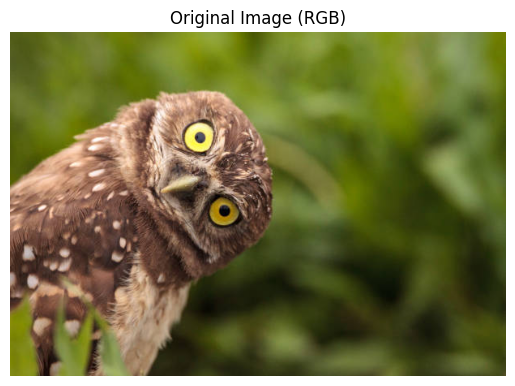

In [31]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()



#### ⚠️ Problem: Direct Intensity Addition

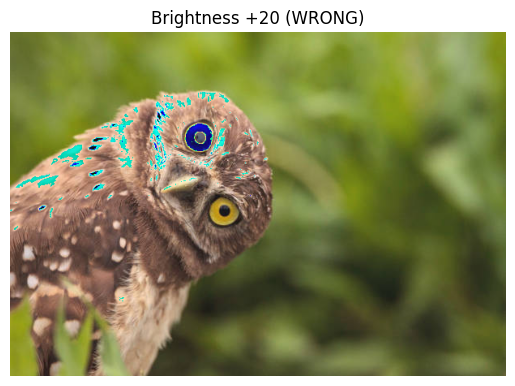

In [32]:
plt.imshow(img_rgb + 20)
plt.title("Brightness +20 (WRONG)")
plt.axis("off")
plt.show()

❗ Why does this break colors?

Because the image is uint8:

valid range → 0 to 255
overflow happens:
250 + 20 → 14 (WRAP AROUND ❌)
10 - 20 → 236 (UNDERFLOW ❌)

📌 Result:

Color distortion and unrealistic image

---

🧠 Correct Approach: Safe Brightness Increase


#### 📌 Convert to higher-bit type (avoid overflow)

In [37]:
img_rgb_safe = img_rgb.astype('int16')

print("After conversion dtype:", img_rgb_safe.dtype)
print("Max value:", img_rgb_safe.max())
print("Min value:", img_rgb_safe.min())

After conversion dtype: int16
Max value: 255
Min value: 0


#### 📌 Increase Brightness

In [38]:
brightness_value = 30
img_rgb_safe += brightness_value

print("dtype:" ,img_rgb_safe.dtype)
print("Max value:" ,img_rgb_safe.max())
print("Min value:" ,img_rgb_safe.min())

dtype: int16
Max value: 285
Min value: 30


#### 📌 Clip values to valid range

In [39]:
img_rgb_safe[img_rgb_safe > 255] = 255

#### 📌 Convert back to uint8

In [41]:
img_rgb_bright = img_rgb_safe.astype('uint8')

#### 📌 Visualize Result

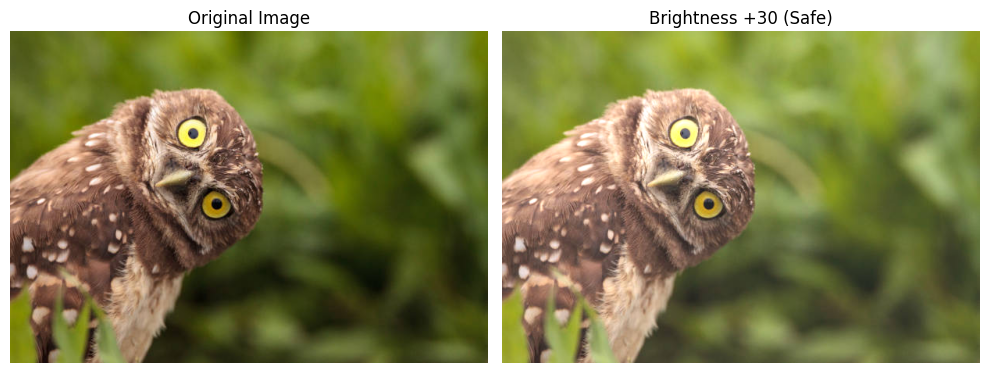

In [42]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rgb_bright)
plt.title("Brightness +30 (Safe)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Decrease Brightness (Safe Method)
#### 📌 Darkening Image

In [43]:
img_rgb_dark = img_rgb.astype('int16')

darkness_value = 30
img_rgb_dark -= darkness_value

#### 📌 Prevent underflow

In [44]:
img_rgb_dark[img_rgb_dark < 0] = 0

#### 📌 Convert back to uint8

In [46]:
img_rgb_dark = img_rgb_dark.astype('uint8')

#### 📌 Compare Results

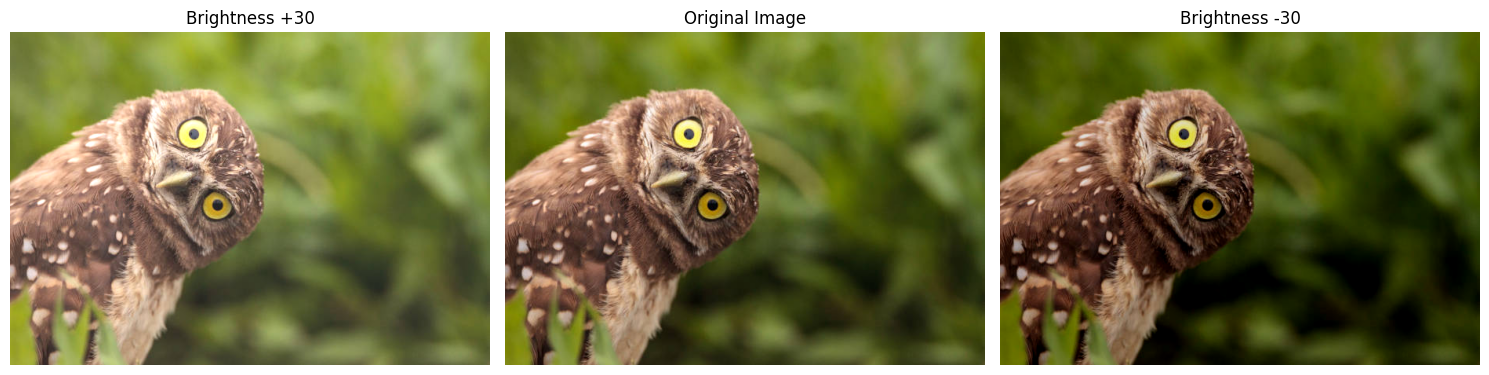

In [47]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb_bright)
plt.title("Brightness +30")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb_dark)
plt.title("Brightness -30")
plt.axis("off")

plt.tight_layout()
plt.show()


# 🧠 Key Concept Summary

## ❌ Wrong Approach

* Direct + / - on uint8
* Causes overflow & underflow
* Results in color distortion

---

## ✅ Correct Approach (Professional Pipeline)

```text
uint8 → int16 → processing → clip → uint8
```

---

## 📌 Why this works?

* `int16` allows negative values
* prevents wrap-around
* `clip()` enforces valid pixel range (0–255)
* final conversion restores image format

